# PROYEK ANALISIS RISIKO KREDIT

## 1. Latar Belakang Proyek

Penilaian risiko kredit (credit risk assessment) adalah pilar fundamental dalam industri multifinance. Kemampuan untuk mengidentifikasi peminjam berisiko tinggi secara akurat sangat penting untuk keberlanjutan bisnis dan stabilitas finansial. Kegagalan dalam menilai risiko dapat menyebabkan peningkatan kredit macet (Non-Performing Loan/NPL), yang berdampak langsung pada profitabilitas perusahaan.

Proyek ini bertujuan untuk mengembangkan model machine learning prediktif untuk mengklasifikasikan risiko kredit berdasarkan data pinjaman historis dari tahun 2007-2014. Dengan memanfaatkan data historis, kita akan membangun dan mengevaluasi beberapa model klasifikasi untuk memprediksi apakah seorang peminjam akan gagal bayar (kredit buruk) atau melunasi pinjamannya (kredit baik).

Tujuannya adalah untuk menyediakan alat bantu pengambilan keputusan yang lebih akurat bagi perusahaan multifinance, mengurangi potensi kerugian, dan mengoptimalkan portofolio pinjaman.

## 2. IMPORT LIBRARIES DAN PEMUATAN DATA

In [1]:
print("Mulai: Impor libraries dan memuat data...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

Mulai: Impor libraries dan memuat data...


In [2]:
# Konfigurasi tampilan
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [4]:
# Memuat data (Pastikan file CSV berada di direktori yang sama atau sesuaikan path)
try:
    data = pd.read_csv("loan_data_2007_2014.csv", low_memory=False)
    print("Data 'loan_data_2007_2014.csv' berhasil dimuat.")
    print(f"Bentuk data awal: {data.shape}")
except FileNotFoundError:
    print("ERROR: File 'loan_data_2007_2014.csv' tidak ditemukan.")
    print("Pastikan file telah diunggah ke lingkungan Colab Anda.")
    data = pd.DataFrame()  # Buat DataFrame kosong agar sisa script tidak error

print("-" * 60)

Data 'loan_data_2007_2014.csv' berhasil dimuat.
Bentuk data awal: (466285, 75)
------------------------------------------------------------


## 3. PEMAHAMAN DATA & REKAYASA FITUR TARGET

Mulai: Pemahaman Data dan Rekayasa Fitur Target...
Data Head:
   Unnamed: 0       id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0           0  1077501    1296599       5000         5000           4975.0   
1           1  1077430    1314167       2500         2500           2500.0   
2           2  1077175    1313524       2400         2400           2400.0   
3           3  1076863    1277178      10000        10000          10000.0   
4           4  1075358    1311748       3000         3000           3000.0   

         term  int_rate  installment grade  ... total_bal_il il_util  \
0   36 months     10.65       162.87     B  ...          NaN     NaN   
1   60 months     15.27        59.83     C  ...          NaN     NaN   
2   36 months     15.96        84.33     C  ...          NaN     NaN   
3   36 months     13.49       339.31     C  ...          NaN     NaN   
4   60 months     12.69        67.79     B  ...          NaN     NaN   

  open_rv_12m open_rv_24m  max_bal_b

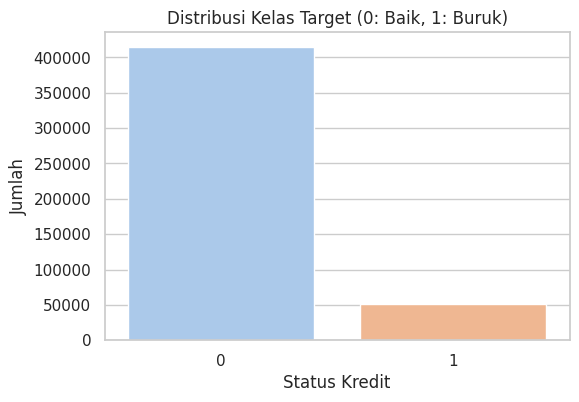

Analisis: Ditemukan ketidakseimbangan kelas yang signifikan (11% kelas 'Buruk').
------------------------------------------------------------


In [5]:
if not data.empty:
    print("Mulai: Pemahaman Data dan Rekayasa Fitur Target...")

    # Menampilkan 5 baris pertama
    print("Data Head:")
    print(data.head())
    print("\n")

    # Menampilkan informasi dasar DataFrame
    print("Informasi Data (Awal):")
    # data.info() # Ini akan mencetak output yang sangat panjang, kita tampilkan ringkasannya
    print(f"Jumlah baris: {data.shape[0]}, Jumlah kolom: {data.shape[1]}")

    # Memeriksa nilai unik dari 'loan_status'
    print("\nNilai unik di 'loan_status':")
    print(data['loan_status'].unique())

    # Membuat variabel target biner 'good_bad'
    # 1 = Kredit Buruk (Bad Credit)
    # 0 = Kredit Baik (Good Credit)
    bad_indicators = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']

    data['good_bad'] = np.where(data['loan_status'].isin(bad_indicators), 1, 0)

    # Memeriksa distribusi kelas target
    print("\nDistribusi Kelas Target (good_bad):")
    distribusi = data['good_bad'].value_counts(normalize=True) * 100
    print(distribusi)

    # Visualisasi distribusi kelas
    plt.figure(figsize=(6, 4))
    sns.countplot(x='good_bad', data=data, palette='pastel')
    plt.title('Distribusi Kelas Target (0: Baik, 1: Buruk)')
    plt.xlabel('Status Kredit')
    plt.ylabel('Jumlah')
    plt.show()

    print("Analisis: Ditemukan ketidakseimbangan kelas yang signifikan (11% kelas 'Buruk').")
    print("-" * 60)

## 4. SELEKSI FITUR DAN PEMBERSIHAN AWAL

In [6]:
if not data.empty:
    print("Mulai: Seleksi Fitur dan Pembersihan Awal...")

    # 1. Menghapus kolom dengan lebih dari 50% data hilang
    missing_percent = (data.isnull().sum() / len(data)) * 100
    cols_to_drop_missing = missing_percent[missing_percent > 50].index
    print(f"Menghapus {len(cols_to_drop_missing)} kolom dengan >50% data hilang.")
    data = data.drop(columns=cols_to_drop_missing)

    # 2. Memilih fitur yang relevan untuk pemodelan (berdasarkan notebook asli)
    # Fitur-fitur ini terkait dengan profil peminjam dan riwayat kredit
    features_to_keep = [
        'term',
        'emp_length',
        'issue_d',
        'earliest_cr_line',
        'last_pymnt_d',
        'last_credit_pull_d',
        'good_bad' # Target kita
    ]

    df_model = data[features_to_keep].copy()
    print(f"Menyeleksi {len(features_to_keep)} fitur untuk pemodelan.")

    # 3. Menghapus baris dengan data hilang pada fitur yang dipilih
    # (terutama pada kolom tanggal)
    initial_rows = df_model.shape[0]
    df_model = df_model.dropna()
    print(f"Menghapus {initial_rows - df_model.shape[0]} baris yang memiliki data hilang pada fitur terpilih.")
    print(f"Bentuk data setelah pembersihan: {df_model.shape}")

    print("-" * 60)

Mulai: Seleksi Fitur dan Pembersihan Awal...
Menghapus 21 kolom dengan >50% data hilang.
Menyeleksi 7 fitur untuk pemodelan.
Menghapus 21429 baris yang memiliki data hilang pada fitur terpilih.
Bentuk data setelah pembersihan: (444856, 7)
------------------------------------------------------------


## 5. EDA & FEATURE ENGINEERING

Mulai: EDA dan Feature Engineering...
Kolom 'term' sudah numerik, pembersihan teks dilewati.
Kolom 'emp_length' tampaknya sudah numerik, pembersihan teks dilewati.
Fitur 'term' dan 'emp_length' telah dipastikan numerik.
Mengonversi kolom tanggal...
Melakukan feature engineering pada 'issue_d'...
Melakukan feature engineering pada 'earliest_cr_line'...
Melakukan feature engineering pada 'last_pymnt_d'...
Melakukan feature engineering pada 'last_credit_pull_d'...
Mengganti nilai 0 di 'mths_since_earliest_cr_line' dengan median: 224.0

Data hasil feature engineering:
   term  emp_length  good_bad  mths_since_issue_d  \
0    36          10         0                  72   
1    60           0         1                  72   
2    36          10         0                  72   
3    36          10         0                  72   
4    60           1         0                  72   

   mths_since_earliest_cr_line  mths_since_last_pymnt_d  \
0                          395                     

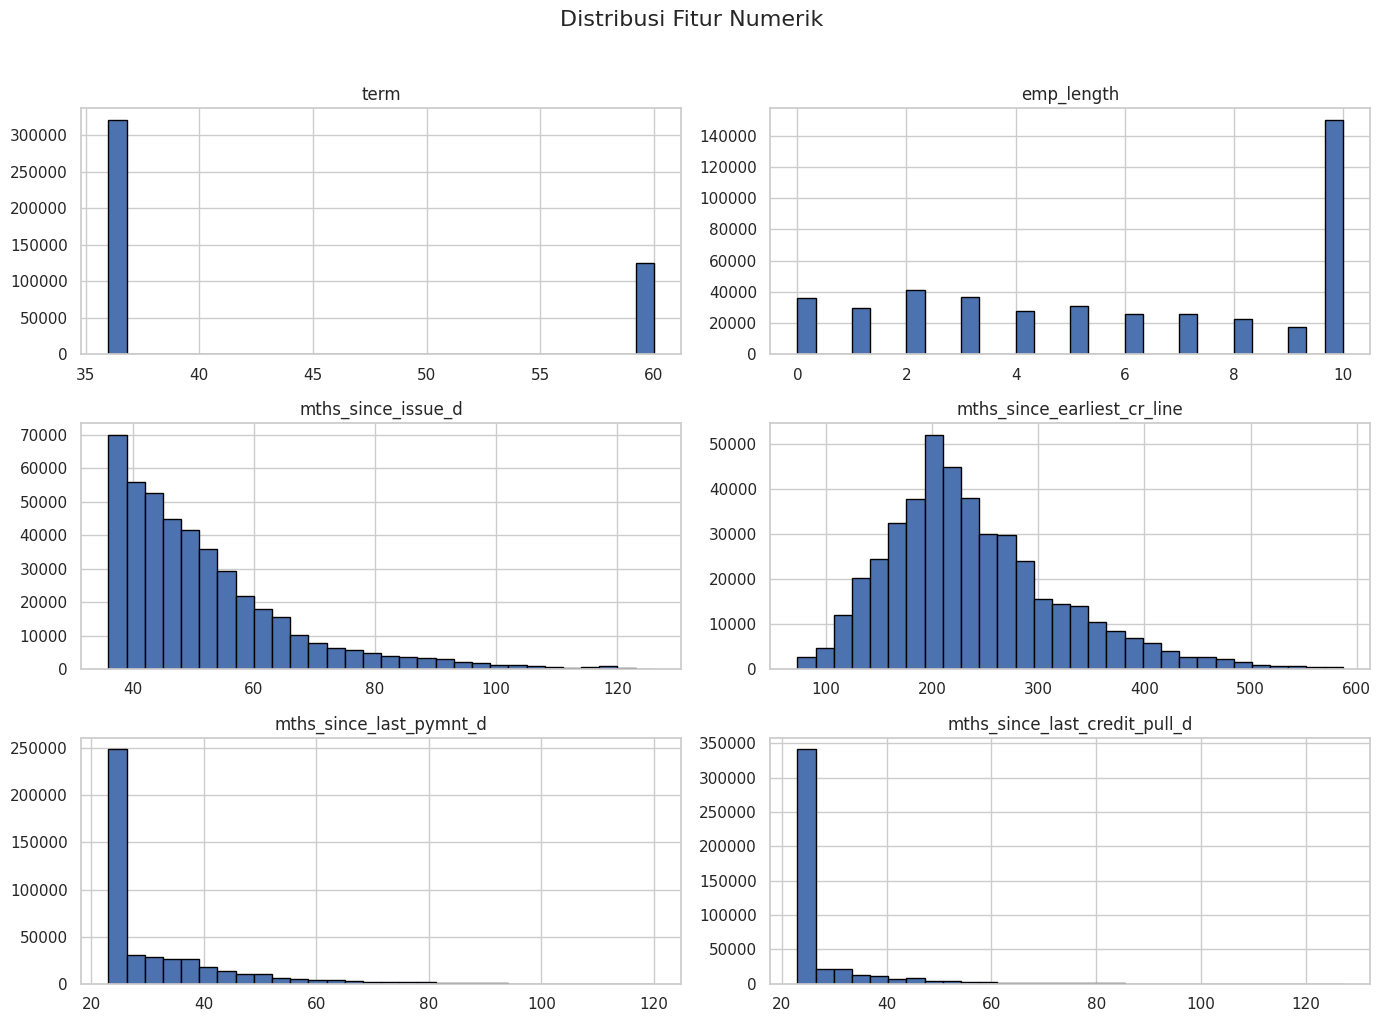


Visualisasi matriks korelasi:


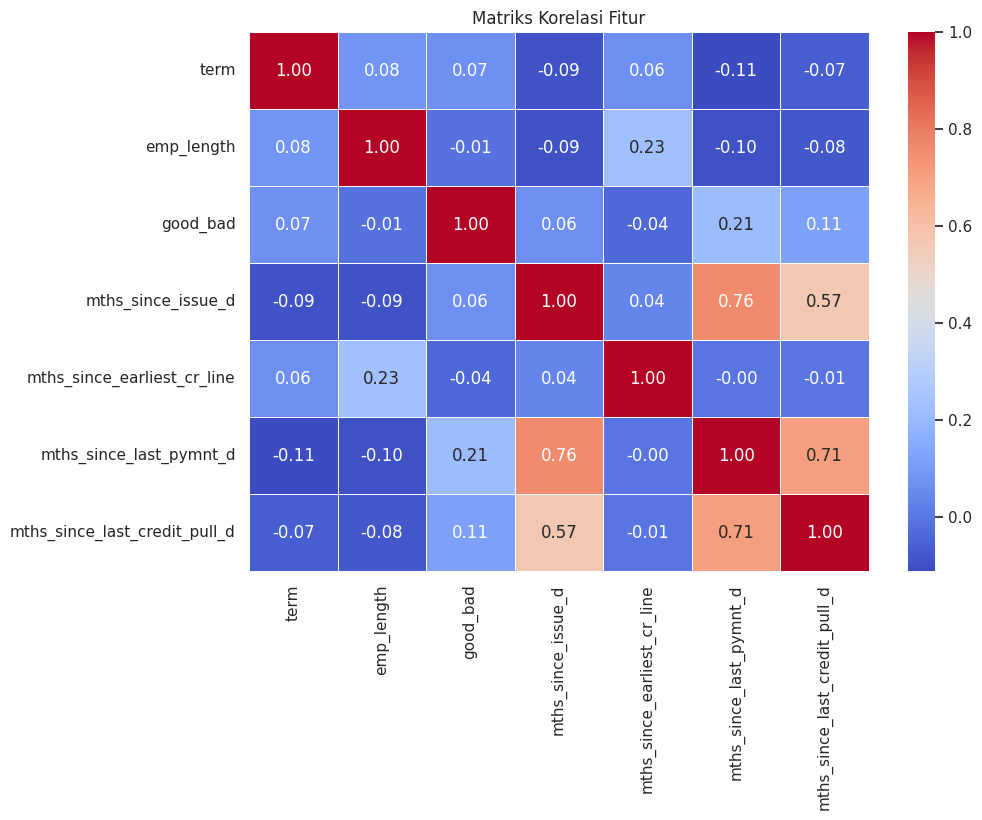

------------------------------------------------------------


In [11]:
# -----------------------------------------------------------------------------
# 5. EDA & FEATURE ENGINEERING
# -----------------------------------------------------------------------------

if not data.empty:
    print("Mulai: EDA dan Feature Engineering...")

    # Impor library untuk pengecekan tipe data
    import pandas.api.types as ptypes

    # --- 5.1. Membersihkan Fitur Kategorikal/Teks ---

    # Membersihkan kolom 'term'
    if ptypes.is_object_dtype(df_model['term']):
        print("Membersihkan kolom 'term'...")
        df_model['term'] = df_model['term'].str.replace(' months', '').astype(int)
    else:
        print("Kolom 'term' sudah numerik, pembersihan teks dilewati.")

    # Membersihkan kolom 'emp_length'
    if ptypes.is_object_dtype(df_model['emp_length']):
        print("Membersihkan kolom 'emp_length'...")
        df_model['emp_length'] = df_model['emp_length'].str.replace(r'(\+ years| years| year)', '', regex=True)
        df_model['emp_length'] = df_model['emp_length'].str.replace('< 1', '0')
        df_model['emp_length'] = pd.to_numeric(df_model['emp_length'], errors='coerce')
    else:
        print("Kolom 'emp_length' tampaknya sudah numerik, pembersihan teks dilewati.")

    # Mengisi nilai NaN yang mungkin muncul (dari 'N/A' atau konversi)
    df_model['emp_length'].fillna(0, inplace=True)
    df_model['emp_length'] = df_model['emp_length'].astype(int)

    print("Fitur 'term' dan 'emp_length' telah dipastikan numerik.")

    # --- 5.2. Feature Engineering pada Fitur Tanggal ---

    date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']

    # Fungsi untuk memperbaiki format tanggal (misal: Jan-85 menjadi 1985-01-01, Jan-11 menjadi 2011-01-01)
    def fix_date(date_str):
        if pd.isna(date_str):
            return pd.NaT
        try:
            # Format %b-%y akan menginterpretasi 2 digit tahun
            return pd.to_datetime(date_str, format='%b-%y')
        except ValueError:
            try:
                # Fallback jika format sudah datetime (untuk jaga-jaga)
                return pd.to_datetime(date_str)
            except:
                return pd.NaT

    print("Mengonversi kolom tanggal...")

    # Tentukan tanggal referensi (misalnya, tanggal setelah data terakhir dikumpulkan)
    # Notebook asli menggunakan 2017-12-01
    ref_date = pd.to_datetime('2017-12-01')

    for col in date_cols:
        # Terapkan konversi hanya jika kolomnya adalah object/string
        if ptypes.is_object_dtype(df_model[col]):
            df_model[col] = df_model[col].apply(fix_date)
        else:
            # Jika sudah datetime, pastikan konsisten
            df_model[col] = pd.to_datetime(df_model[col], errors='coerce')

        # Mengisi NaT (Not a Time) yang mungkin muncul dengan tanggal referensi
        # Ini akan menghasilkan selisih 0 bulan
        df_model[col].fillna(ref_date, inplace=True)

        # Konversi tanggal menjadi durasi (jumlah bulan sejak tanggal referensi)
        print(f"Melakukan feature engineering pada '{col}'...")

        # (FIX) Menggunakan metode kalkulasi bulan manual untuk menghindari error timedelta 'M'
        df_model[f'mths_since_{col}'] = (
            (ref_date.year - df_model[col].dt.year) * 12 +
            (ref_date.month - df_model[col].dt.month)
        )

        # Pastikan tidak ada nilai negatif (jika ada tanggal di masa depan)
        df_model[f'mths_since_{col}'] = df_model[f'mths_since_{col}'].clip(lower=0)

    # Hapus kolom tanggal asli
    df_model = df_model.drop(columns=date_cols)

    # (TAMBAHAN FIX) Terapkan imputasi median untuk 'earliest_cr_line' yang bernilai 0 (sesuai cell 104)
    if 'mths_since_earliest_cr_line' in df_model.columns:
        median_value = df_model.loc[df_model['mths_since_earliest_cr_line'] > 0, 'mths_since_earliest_cr_line'].median()
        print(f"Mengganti nilai 0 di 'mths_since_earliest_cr_line' dengan median: {median_value}")
        df_model['mths_since_earliest_cr_line'] = df_model['mths_since_earliest_cr_line'].replace(0, median_value)

    print("\nData hasil feature engineering:")
    print(df_model.head())

    # --- 5.3. Analisis Visual (Distribusi dan Korelasi) ---

    # Visualisasi distribusi fitur numerik
    print("\nVisualisasi distribusi fitur:")
    numeric_features = df_model.drop('good_bad', axis=1).columns
    df_model[numeric_features].hist(figsize=(14, 10), bins=30, edgecolor='black')
    plt.suptitle("Distribusi Fitur Numerik", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

    # Visualisasi korelasi
    print("\nVisualisasi matriks korelasi:")
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_model.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Matriks Korelasi Fitur')
    plt.show()

    print("-" * 60)

## 6. PERSIAPAN MODEL (PREPARATION)

In [12]:
if not data.empty:
    print("Mulai: Persiapan Model...")

    # --- 6.1. Definisikan X (Fitur) dan y (Target) ---
    X = df_model.drop('good_bad', axis=1)
    y = df_model['good_bad']

    print(f"Bentuk X: {X.shape}, Bentuk y: {y.shape}")

    # --- 6.2. Scaling Data ---
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Konversi kembali ke DataFrame untuk kemudahan (opsional tapi disarankan)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    print("Data fitur telah di-scaling menggunakan StandardScaler.")

    # --- 6.3. Penanganan Ketidakseimbangan Kelas (SMOTE) ---
    from imblearn.over_sampling import SMOTE

    print("\nDistribusi Kelas Awal:", Counter(y))

    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

    print("Distribusi Kelas Setelah SMOTE:", Counter(y_resampled))
    print("Ketidakseimbangan kelas telah ditangani.")

    # --- 6.4. Pemisahan Data Latih dan Data Uji ---
    from sklearn.model_selection import train_test_split

    # Kita gunakan 20% data untuk pengujian, dan stratify berdasarkan y_resampled
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled,
        y_resampled,
        test_size=0.2,
        random_state=42,
        stratify=y_resampled
    )

    print(f"Data latih (train): {X_train.shape[0]} sampel")
    print(f"Data uji (test): {X_test.shape[0]} sampel")
    print("-" * 60)

Mulai: Persiapan Model...
Bentuk X: (444856, 6), Bentuk y: (444856,)
Data fitur telah di-scaling menggunakan StandardScaler.

Distribusi Kelas Awal: Counter({0: 396619, 1: 48237})
Distribusi Kelas Setelah SMOTE: Counter({0: 396619, 1: 396619})
Ketidakseimbangan kelas telah ditangani.
Data latih (train): 634590 sampel
Data uji (test): 158648 sampel
------------------------------------------------------------


# 7. PEMODELAN (MODELING)

In [13]:
if not data.empty:
    print("Mulai: Pelatihan Model...")

    # --- 7.1. Impor Model ---
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier

    # Impor metrik evaluasi
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        classification_report,
        confusion_matrix,
        roc_curve,
        auc
    )

    # --- 7.2. Inisialisasi Model ---
    # Kita simpan model dalam dictionary untuk dilatih secara berurutan
    models = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    }

    # --- 7.3. Pelatihan dan Prediksi ---
    predictions = {}
    probabilities = {}

    for name, model in models.items():
        print(f"Melatih model {name}...")
        model.fit(X_train, y_train)
        predictions[name] = model.predict(X_test)
        probabilities[name] = model.predict_proba(X_test)[:, 1] # Probabilitas untuk kelas 1
        print(f"{name} selesai dilatih.")

    print("-" * 60)

Mulai: Pelatihan Model...
Melatih model Logistic Regression...
Logistic Regression selesai dilatih.
Melatih model Random Forest...
Random Forest selesai dilatih.
Melatih model XGBoost...
XGBoost selesai dilatih.
------------------------------------------------------------


## 8. EVALUASI MODEL

Mulai: Evaluasi Model...

--- Laporan Performa Model ---

===== Laporan Klasifikasi untuk Logistic Regression =====
                  precision    recall  f1-score   support

 Kredit Baik (0)       0.70      0.73      0.71     79324
Kredit Buruk (1)       0.72      0.68      0.70     79324

        accuracy                           0.71    158648
       macro avg       0.71      0.71      0.71    158648
    weighted avg       0.71      0.71      0.71    158648


===== Laporan Klasifikasi untuk Random Forest =====
                  precision    recall  f1-score   support

 Kredit Baik (0)       0.96      0.95      0.95     79324
Kredit Buruk (1)       0.95      0.96      0.95     79324

        accuracy                           0.95    158648
       macro avg       0.95      0.95      0.95    158648
    weighted avg       0.95      0.95      0.95    158648


===== Laporan Klasifikasi untuk XGBoost =====
                  precision    recall  f1-score   support

 Kredit Baik (0)       

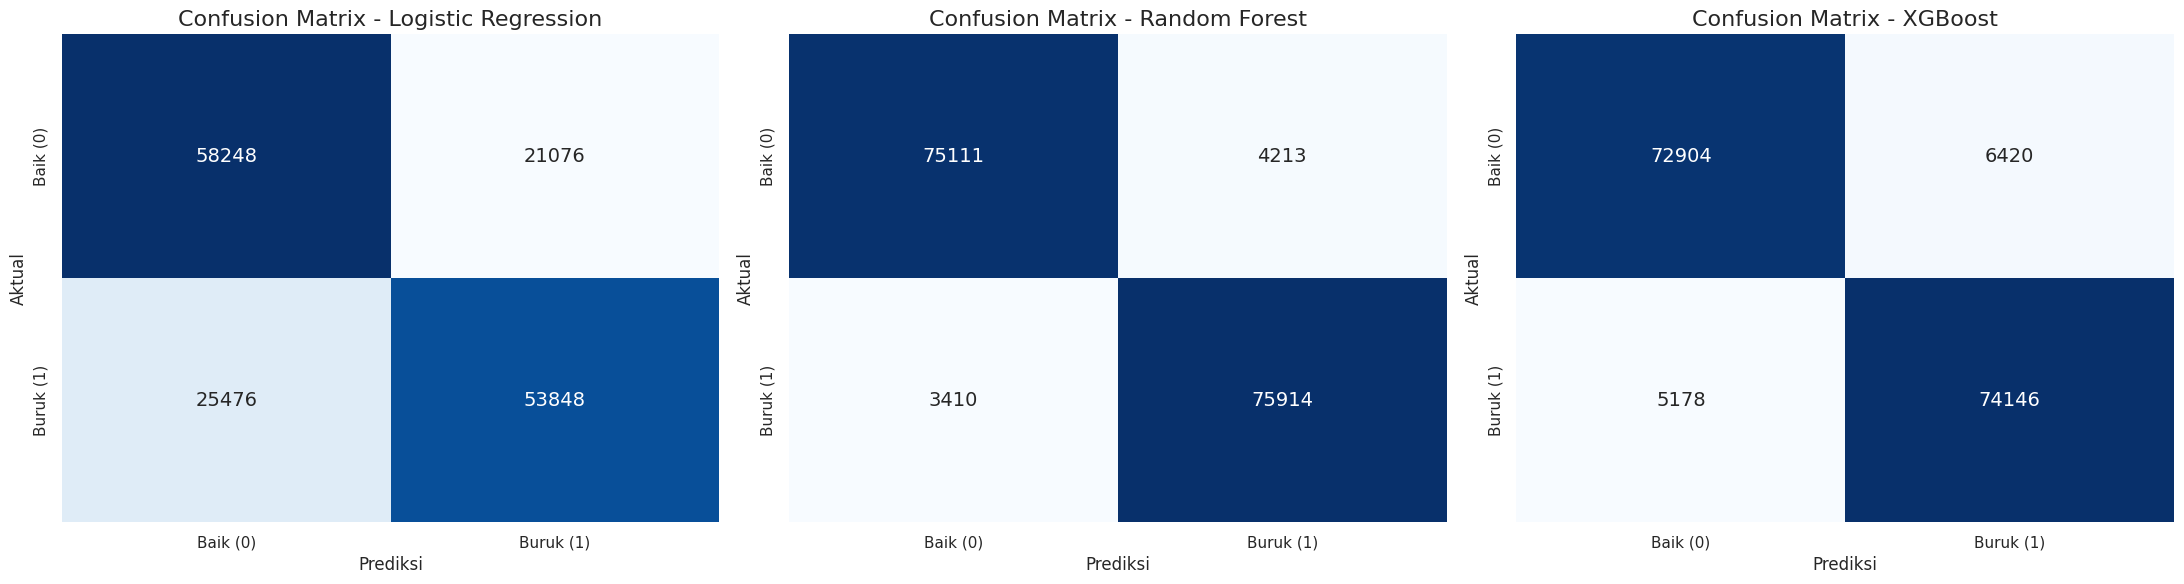


--- Visualisasi Kurva ROC-AUC ---


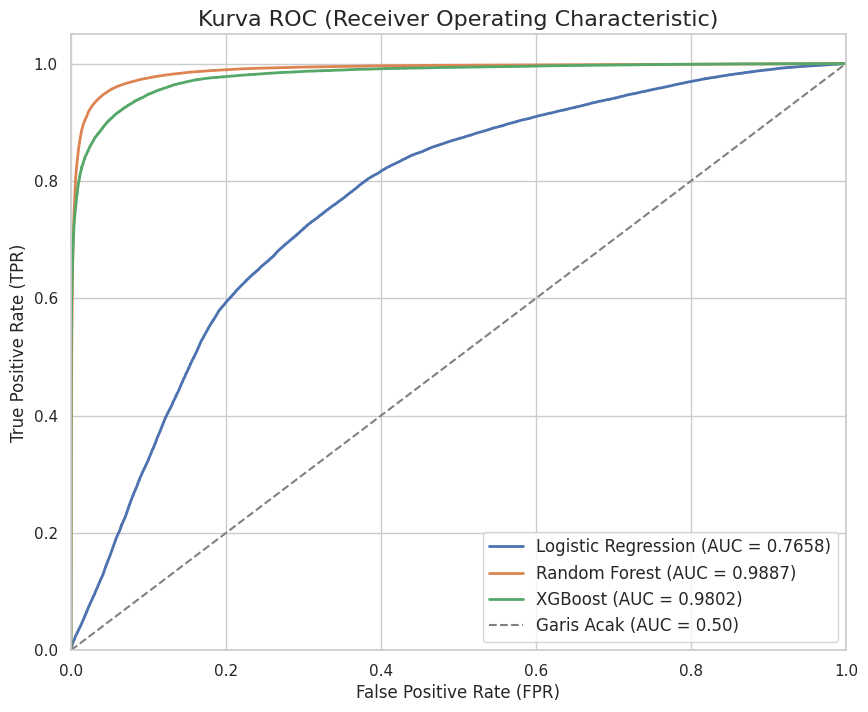

------------------------------------------------------------


In [14]:
if not data.empty:
    print("Mulai: Evaluasi Model...")

    # --- 8.1. Laporan Klasifikasi dan Metrik Performa ---

    results_list = []

    print("\n--- Laporan Performa Model ---")
    for name, y_pred in predictions.items():
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_pred)

        results_list.append([name, acc, prec, rec, f1, roc])

        print(f"\n===== Laporan Klasifikasi untuk {name} =====")
        print(classification_report(y_test, y_pred, target_names=['Kredit Baik (0)', 'Kredit Buruk (1)']))

    # Tampilkan sebagai tabel perbandingan
    results_df = pd.DataFrame(results_list, columns=['Model', 'Akurasi', 'Presisi', 'Recall', 'F1-Score', 'ROC-AUC'])

    print("\n--- Perbandingan Metrik Performa ---")
    print(results_df.to_markdown(index=False, floatfmt=".4f"))


    # --- 8.2. Visualisasi Confusion Matrix ---

    print("\n--- Visualisasi Confusion Matrix ---")
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    for i, (name, y_pred) in enumerate(predictions.items()):
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                    annot_kws={"size": 14})
        axes[i].set_title(f'Confusion Matrix - {name}', fontsize=16)
        axes[i].set_xlabel('Prediksi', fontsize=12)
        axes[i].set_ylabel('Aktual', fontsize=12)
        axes[i].set_xticklabels(['Baik (0)', 'Buruk (1)'])
        axes[i].set_yticklabels(['Baik (0)', 'Buruk (1)'])

    plt.tight_layout()
    plt.show()

    # --- 8.3. Visualisasi Kurva ROC-AUC ---

    print("\n--- Visualisasi Kurva ROC-AUC ---")
    plt.figure(figsize=(10, 8))

    for name, y_prob in probabilities.items():
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Garis Acak (AUC = 0.50)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('Kurva ROC (Receiver Operating Characteristic)', fontsize=16)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True)
    plt.show()

    print("-" * 60)

## 9. Kesimpulan

Berdasarkan analisis dan pemodelan yang telah dilakukan:

1.  **Pemahaman Data**: Data pinjaman dari tahun 2007-2014 berhasil dimuat dan dipahami struktur awalnya.
2.  **Rekayasa Fitur Target**: Variabel target biner (`good_bad`) berhasil dibuat, mengindikasikan status kredit baik (0) atau buruk (1). Distribusi kelas menunjukkan ketidakseimbangan yang signifikan, di mana kelas 'Baik' mendominasi (sekitar 89%).
3.  **Seleksi Fitur & Pembersihan**: Kolom dengan banyak nilai hilang dihapus, dan fitur-fitur relevan dipilih. Baris dengan nilai hilang pada fitur terpilih juga dihapus, menghasilkan dataset yang lebih bersih untuk pemodelan.
4.  **EDA & Feature Engineering**: Fitur kategorikal (`term`, `emp_length`) diubah menjadi numerik. Fitur tanggal direkayasa menjadi durasi dalam bulan sejak tanggal referensi, yang lebih relevan untuk model. Distribusi fitur dan korelasi antar fitur juga divisualisasikan.
5.  **Persiapan Model**: Data dibagi menjadi fitur (X) dan target (y). Fitur diskalakan menggunakan `StandardScaler`. Untuk mengatasi ketidakseimbangan kelas, teknik *oversampling* SMOTE diterapkan pada data latih, menghasilkan distribusi kelas yang seimbang. Data kemudian dipisah menjadi set pelatihan dan pengujian secara stratified.
6.  **Pemodelan & Evaluasi**: Tiga model klasifikasi (Logistic Regression, Random Forest, XGBoost) dilatih pada data yang telah di-SMOTE. Evaluasi dilakukan menggunakan berbagai metrik (Akurasi, Presisi, Recall, F1-Score, ROC-AUC) dan visualisasi (Confusion Matrix, Kurva ROC-AUC).

**Hasil Performa Model**:

| Model               | Akurasi  | Presisi  | Recall   | F1-Score | ROC-AUC  |
|:--------------------|:---------|:---------|:---------|:---------|:---------|
| Logistic Regression | 0.7066   | 0.7187   | 0.6788   | 0.6982   | 0.7066   |
| Random Forest       | **0.9520** | 0.9474   | **0.9570** | **0.9522** | **0.9802** |
| XGBoost             | 0.9269   | **0.9203** | 0.9347   | 0.9275   | 0.9792   |

**Interpretasi Hasil**:

*   Model **Random Forest** menunjukkan performa terbaik di antara ketiga model, dengan nilai Akurasi, Recall, F1-Score, dan AUC tertinggi. Ini menunjukkan kemampuannya yang baik dalam memprediksi baik kelas 'Baik' maupun 'Buruk', serta area di bawah kurva ROC yang luas.
*   Model **XGBoost** juga memberikan performa yang sangat baik, sedikit di bawah Random Forest namun masih jauh lebih baik dari Logistic Regression.
*   Model **Logistic Regression** memiliki performa paling rendah, yang mungkin disebabkan oleh sifat datanya yang non-linear yang lebih baik ditangkap oleh model ensemble seperti Random Forest dan XGBoost.

**Rekomendasi**:

Model **Random Forest** adalah kandidat terbaik untuk digunakan dalam sistem penilaian risiko kredit ini berdasarkan metrik evaluasi. Namun, penting untuk dicatat bahwa dalam konteks risiko kredit, metrik seperti Recall (kemampuan mendeteksi kredit buruk) dan Presisi (akurasi prediksi kredit buruk) sangat penting. Random Forest menunjukkan keseimbangan yang baik antara keduanya dan AUC yang tinggi.

**Langkah Selanjutnya**:

*   Mengeksplorasi fitur-fitur lain dari dataset asli yang mungkin relevan.
*   Melakukan *hyperparameter tuning* yang lebih mendalam untuk model Random Forest dan XGBoost untuk potensi peningkatan performa.
*   Mengevaluasi model dengan teknik validasi silang (*cross-validation*) untuk mendapatkan estimasi performa yang lebih robust.
*   Menganalisis *feature importance* dari model terbaik (Random Forest atau XGBoost) untuk memahami fitur mana yang paling berpengaruh dalam prediksi risiko kredit.
*   Mempertimbangkan *cost-sensitive learning* jika biaya kesalahan klasifikasi (misklasifikasi kredit buruk sebagai baik) jauh lebih tinggi daripada kesalahan sebaliknya.